Hybrid CNN + LSTM for Fake News Detection

## Table of Contents

- [Import Libraries and Load Data](#import-libraries-and-load-data)
- [Text Tokenization and Embedding Matrix (GloVe)](#text-tokenization-and-embedding-matrix-glove)
- [Define Models](#define-models)
    - [Hybrid CNN + LSTM](#hybrid-cnn--lstm)
    - [LSTM](#lstm)
- [Train and Evaluate Models](#train-and-evaluate-models)
    - [Hybrid CNN + LSTM Training](#hybrid-cnn--lstm-training)
    - [LSTM Training](#lstm-training)

## Import Libraries and Load Data

In [ ]:
import re
import random
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint


In [ ]:
data = pd.read_csv("FA-KES-Dataset.csv", encoding='latin1')
data.head()

      unit_id                                      article_title  \
0  1914947530  Syria attack symptoms consistent with nerve ag...   
1  1914947532  Homs governor says U.S. attack caused deaths b...   
2  1914947533    Death toll from Aleppo bomb attack at least 112   
3  1914947534        Aleppo bomb blast kills six Syrian state TV   
4  1914947535  29 Syria Rebels Dead in Fighting for Key Alepp...   

                                     article_content source       date  \
0  Wed 05 Apr 2017 Syria attack symptoms consiste...    nna   4/5/2017   
1  Fri 07 Apr 2017 at 0914 Homs governor says U.S...    nna   4/7/2017   
2  Sun 16 Apr 2017 Death toll from Aleppo bomb at...    nna  4/16/2017   
3  Wed 19 Apr 2017 Aleppo bomb blast kills six Sy...    nna  4/19/2017   
4  Sun 10 Jul 2016 29 Syria Rebels Dead in Fighti...    nna  7/10/2016   

  location  labels  
0    idlib       0  
1     homs       0  
2   aleppo       0  
3   aleppo       0  
4   aleppo       0  


In [3]:
print(data.isnull().sum())
X = data.drop(columns=['labels'])
Y = data['labels']

unit_id            0
article_title      0
article_content    0
source             0
date               0
location           0
labels             0
dtype: int64


In [ ]:
# Make a copy of the dataset to avoid modifying the original DataFrame.
messages = X.copy()

# Reset index for clean sequential indexing.
messages.reset_index(inplace=True)

## Text Tokenization and Embedding Matrix (GloVe)

In [ ]:
# 1. Download and extract GloVe (100d)

# !wget -q https://nlp.stanford.edu/data/glove.6B.zip
# !unzip -q glove.6B.zip

In [ ]:
MAX_VOCAB_SIZE = 20000  # voc_size
EMBEDDING_DIM = 100     # embedding_vector_features
MAX_SEQ_LEN = 300       # sent_length

In [ ]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(messages['article_content'])

sequences = tokenizer.texts_to_sequences(messages['article_content'])
padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_SEQ_LEN,
    padding="post",
    truncating="post"
)  # padded_sequences → ready to feed into model

word_index = tokenizer.word_index
num_words = min(MAX_VOCAB_SIZE, len(word_index) + 1)

print(f"Vocabulary size used: {num_words}")
print("Padded sequences shape:", padded_sequences.shape)


Vocabulary size used: 10179
Padded sequences shape: (804, 300)


In [ ]:
# Load GloVe vectors
embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Loaded {len(embeddings_index)} word vectors from GloVe")


Loaded 400000 word vectors from GloVe


In [ ]:
# Build embedding matrix
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

for word, idx in word_index.items():
    if idx >= MAX_VOCAB_SIZE:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector

print("Embedding matrix shape:", embedding_matrix.shape)

# embedding_matrix → Initial weights for embedding layer

Embedding matrix shape: (10179, 100)


## Define Models


### Hybrid CNN + LSTM

In [ ]:
#   1. Embedding(voc_size, embedding_vector_features, input_length=sent_length)
#   2. Conv1D with 128 filters and kernel size 5, activation="relu"
#   3. MaxPooling1D with pool size 2
#   4. LSTM layer with 32 units
#   5. Dense layer with 1 unit and sigmoid activation

# Keras Embedding layer (GloVe-initialized)
embedding_layer_hybrid = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=True
)

model = Sequential(name='Hybrid')
model.add(Input(shape=(MAX_SEQ_LEN,)))
model.add(embedding_layer_hybrid)
model.add(Conv1D(128, kernel_size=5, activation="relu"))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(32))
model.add(Dense(1, activation="sigmoid"))

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# Print model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 300, 100)       │     1,017,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 296, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 148, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,102,669 (4.21 MB)

 Trainable params: 1,102,669 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

None


### LSTM

In [ ]:
#   1. Embedding(voc_size, embedding_vector_features, input_length=sent_length)
#   2. LSTM layer with 32 units
#   3. Dense layer with 1 unit and sigmoid activation

# Keras Embedding layer (GloVe-initialized)
embedding_layer_lstm = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=True
)

model_RNN = Sequential(name='LSTM')
model_RNN.add(Input(shape=(MAX_SEQ_LEN,)))
model_RNN.add(embedding_layer_lstm)
model_RNN.add(LSTM(32))
model_RNN.add(Dense(1, activation="sigmoid"))

model_RNN.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# Print RNN model summary
print(model_RNN.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 300, 100)       │     1,017,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,034,957 (3.95 MB)

 Trainable params: 1,034,957 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

None


## Train and Evaluate Models

**TRAIN TEST SPLITTING**

In [ ]:
EPOCHS = 20
BATCH_SIZE = 32
LR = 0.01
TEST_SPLIT = 0.2

In [ ]:
print(padded_sequences.shape)
print(Y.shape)

X_final = np.array(padded_sequences)
Y_final = np.array(Y)
X_final.shape , Y_final.shape

x_train, x_test, y_train, y_test = train_test_split(X_final, Y_final, test_size=TEST_SPLIT, random_state=42)
print(len(x_train))
print(len(x_test))

(804, 300)
(804,)
643
161


### Hybrid CNN + LSTM Training

In [ ]:
filepath = "my_best_model.keras"   # modern Keras format

# Callback to save the model that achieves the best validation accuracy
checkpoint = ModelCheckpoint(
    filepath=filepath,
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

callbacks = [checkpoint]


optimizer = Adam(learning_rate=LR)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/20
19/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5242 - loss: 0.7115
Epoch 1: val_accuracy improved from -inf to 0.49068, saving model to my_best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5227 - loss: 0.7106 - val_accuracy: 0.4907 - val_loss: 0.6963
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5191 - loss: 0.6817
Epoch 2: val_accuracy improved from 0.49068 to 0.56522, saving model to my_best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5196 - loss: 0.6816 - val_accuracy: 0.5652 - val_loss: 0.6894
Epoch 3/20
18/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5620 - loss: 0.6610
Epoch 3: val_accuracy did not improve from 0.56522
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5644 - loss: 0.6621 - val_accuracy: 0.4907 - val_loss: 0.7093
Epoch 4/20
19/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6573 - loss: 0.6440
Epoch 4: val_accuracy did not improve from 0.56522
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 

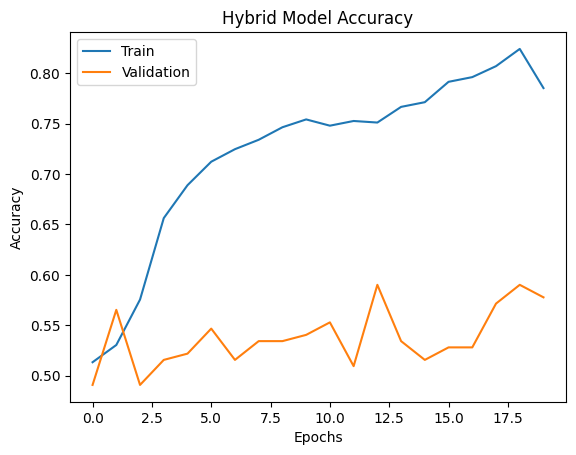

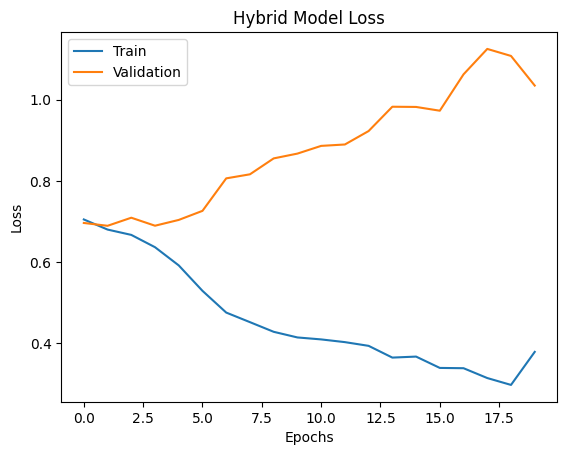

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


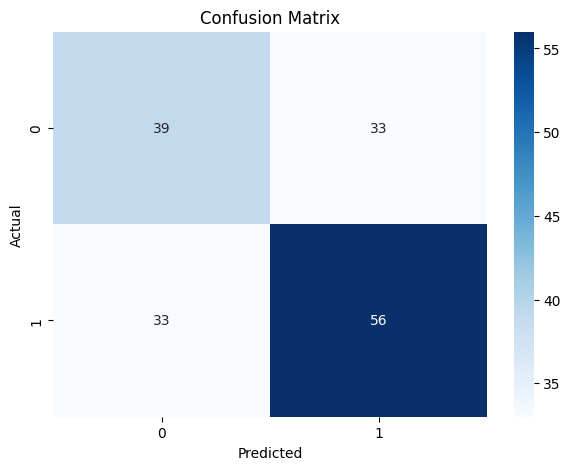

Accuracy: 59.006211180124225


In [62]:
# -----------------------------
# Plot Accuracy
# -----------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Hybrid Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# -----------------------------
# Plot Loss
# -----------------------------
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Hybrid Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# -----------------------------
# Load Best Saved Model
# -----------------------------
model = load_model("my_best_model.keras")

# -----------------------------
# Predict on Test Data
# -----------------------------
preds = model.predict(x_test)
Y_pred = (preds >= 0.5).astype(int).reshape(-1)

# -----------------------------
# Confusion Matrix
# -----------------------------
df_cm = confusion_matrix(y_test, Y_pred)

plt.figure(figsize=(7,5))
sn.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Accuracy Score
# -----------------------------
print("Accuracy:", accuracy_score(y_test, Y_pred) * 100)

In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_test, Y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.54      0.54      0.54        72
           1       0.63      0.63      0.63        89

    accuracy                           0.59       161
   macro avg       0.59      0.59      0.59       161
weighted avg       0.59      0.59      0.59       161



### LSTM Training

In [ ]:
filepath = "my_best_model_RNN.keras"   # modern format

# Callback to save the RNN model achieving the best validation accuracy
checkpoint = ModelCheckpoint(
    filepath=filepath,
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

callbacks = [checkpoint]


optimizer = Adam(learning_rate=LR)
model_RNN.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

history_RNN = model_RNN.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/20
18/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5040 - loss: 0.7000
Epoch 1: val_accuracy improved from -inf to 0.54037, saving model to my_best_model_RNN.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5052 - loss: 0.6994 - val_accuracy: 0.5404 - val_loss: 0.6915
Epoch 2/20
19/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5916 - loss: 0.6774
Epoch 2: val_accuracy improved from 0.54037 to 0.55280, saving model to my_best_model_RNN.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5911 - loss: 0.6777 - val_accuracy: 0.5528 - val_loss: 0.6938
Epoch 3/20
19/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5916 - loss: 0.6651
Epoch 3: val_accuracy did not improve from 0.55280
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5884 - loss: 0.6655 - val_accuracy: 0.5404 - val_loss: 0.6946
Epoch 4/20
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5538 - loss: 0.6604
Epoch 4: val_accuracy did not improve from 0.55280
21/21 ━━━━━━━━━━━━━━━

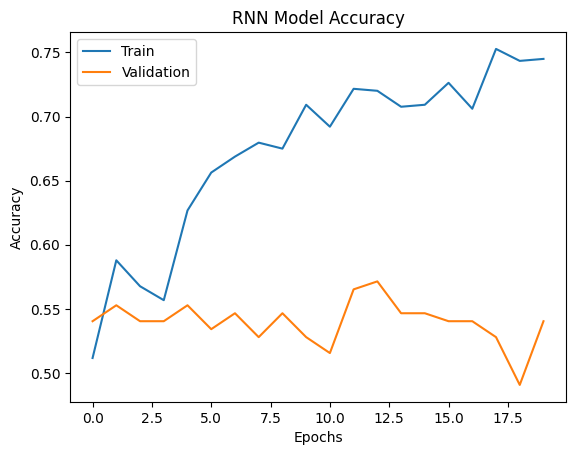

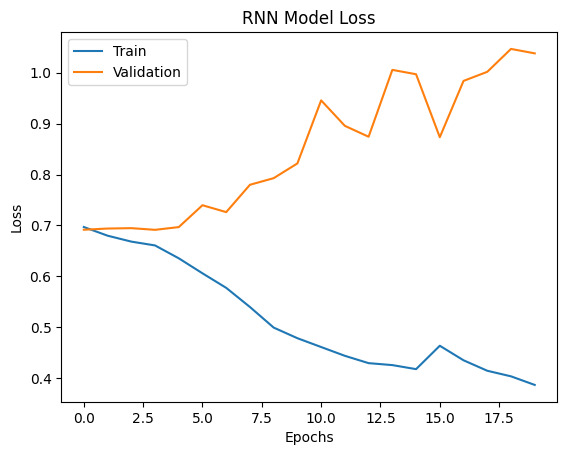

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


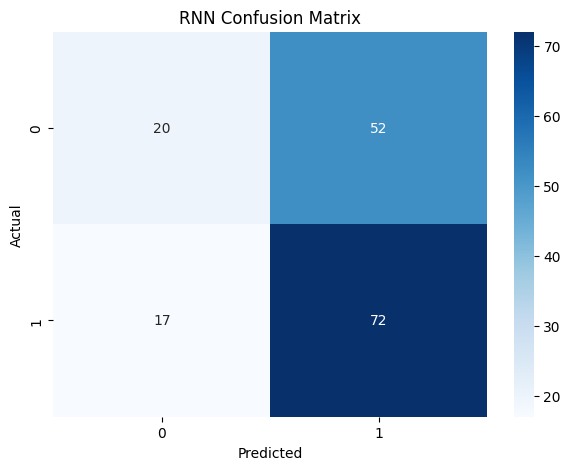

Accuracy: 57.14285714285714


In [65]:
# ============================
#   RNN MODEL EVALUATION
# ============================

# ---- Plot Accuracy ----
plt.plot(history_RNN.history['accuracy'])
plt.plot(history_RNN.history['val_accuracy'])
plt.title('RNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# ---- Plot Loss ----
plt.figure()
plt.plot(history_RNN.history['loss'])
plt.plot(history_RNN.history['val_loss'])
plt.title('RNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# ---- Load Best Saved RNN Model ----
model = load_model('my_best_model_RNN.keras')

# ---- Predict ----
preds = model.predict(x_test)

Y_pred = (preds >= 0.5).astype(int).reshape(-1)

# ---- Confusion Matrix ----
df_cm = confusion_matrix(y_test, Y_pred)

plt.figure(figsize=(7,5))
sn.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('RNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print('Accuracy:', accuracy_score(y_test, Y_pred) * 100)


In [66]:
from sklearn.metrics import classification_report
print(classification_report(y_test, Y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.54      0.28      0.37        72
           1       0.58      0.81      0.68        89

    accuracy                           0.57       161
   macro avg       0.56      0.54      0.52       161
weighted avg       0.56      0.57      0.54       161

